# Georg-August-Universität Göttingen - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Georg-August-Universität Göttingen' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              142 -- 'Georg-August-Universität Göttingen'
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Georg-August-Universität Göttingen,Department of Molecular Oncology University Me...,https://openalex.org/W4399758528
1,not assigned,Georg-August-Universität Göttingen,Clinical Research Unit 5002 University Medical...,https://openalex.org/W4399758528
2,not assigned,Georg-August-Universität Göttingen,Center for Biostructural Imaging of Neurodegen...,https://openalex.org/W4399758528
3,not assigned,Georg-August-Universität Göttingen,Chair of Forest and Nature Conservation Policy...,https://openalex.org/W4397002188
4,not assigned,Georg-August-Universität Göttingen,Georg-August-Universität Göttingen,https://openalex.org/W4398132627


In [1020]:
MAPPING_DICT = {
    'Bernstein Zentrum für Computational Neuroscience Göttingen': ['computational neuroscience', 'bernstein zentrum'], # selbst ergänzt
    'Campus Institut für Dynamik biologischer Netzwerke (CIDBN)': ['biological networks'],
    'Campus-Institut Data Science (CIDAS)': ['cidas', 'campus institute data science'],
    'Centre for Modern Indian Studies (CeMIS)': ['cent(er|re) for modern indian studies'],
    #'Courant Forschungszentrum Armut, Ungleichheit und Wachstum in Entwicklungsländern': [],
    #'Courant Forschungszentrum Bildung und Religion': [],
    #'Courant Forschungszentrum Evolution des Sozialverhaltens': [],
    #'Courant Forschungszentrum Nanospektroskopie und Röntgenbildgebung': [],
    #'Courant Forschungszentrum Geobiologie': [],
    #'Courant-Forschungszentrum Textstrukturen': [],
    #'DFG Forschungszentrum für Molekularphysiologie des Gehirns': [],
    #'Erasmus Mundus Programme Euroculture - Society, politics and culture in a global context': [],
    'Fakultät für Agrarwissenschaften': ['landwirtschaftlich', 'agricultural', 'breeding research', 'veterinary', '(animal|crop) science', 'mycotoxin',
                                         'agro(ecology|biodiversity|nomy)', 'biogeochemistry', 'plant pathology', 'animal medicine', 'husbandry',
                                         'agrarökonomie', 'grassland'
                                        ],
    'Fakultät für Biologie und Psychologie': ['biolog(ie|y) (and|und) psycholog(ie|y)', 'blumenbach', 'evolution of plants', 'georg-elias', 'conservation biology',
                                              '(department|institute) of psychology', '(animal|human|behavioral) ecology', 'climate dynamics', 'applied bioinformatics',
                                              'cent(er|re) (of|for) molecular biosciences', 'von(-|\s)haller', 'plant cell biology', 'zoology and anthropology',
                                              'enzymology', '(educational|developmental) psychology', 'plant ecology', 'mi(k|c)robiolog(ie|y) (und|and) geneti(k|cs)', 
                                              '(socio|neuro)biology', 'psychologie und psychotherapie', 'molecular structural biology', 'biology education',
                                              'psychology of language', 'phycology', '(general|applied) microbiology', 'developmental biology',
                                              'vegetation', '(abteilung|animal) evolution', 'molecular oncology', 'genomic', ' social and communication'
                                             ],
    'Fakultät für Chemie': ['(physi(kalische|cal)|(an|in)organi(sche|c)) chemi(e|st(r)?y)', 'biomole(k|c)ular', '(faculty|department) of chemistry', 'w(ö|oe)hler'
                           ],
    'Fakultät für Forstwissenschaften und Waldökologie': ['centre of biodiversity', 'forest', 'wood', 'biogeography', 'ecosystem modelling',
                                                          'radio(‐|-)?isotopes', '(soil|wildlife) science', 'stable isotope', 'bioclimatology',
                                                          'wildlife', 'forstwissenschaften'
                                                         ],
    'Fakultät für Geowissenschaften und Geographie': ['geo(dynamics|science)', 'mineralog(ie|y)', 'geowissenschaftliches zentrum', '(physical|human) geography',
                                                      'sedimentology', 'cartography', '(angewandte|applied) geolog(ie|y)', '(department|institute) of geo(biology|graphy)',
                                                      'abteilung geochemie', 'geographisches'
                                                     ],
    'Fakultät für Mathematik und Informatik': ['computer science', 'mathemati(k|cs|sch)', 'stochastic', 'bernstein‐institute', 'institut(e)? (für|of) informati(k|cs)',
                                               'maschinelles lernen', 'computer security'
                                              ],
    'Fakultät für Physik': ['geophysik', 'complex systems', 'friedrich-hund', 'x(‐|-)ray physics', 'physics—biophysics', 
                            '(institute|fa(k|c)ult(ät|y)|department) (der|für|of) physi(k|cs)', 
                            'physi(kalisches|cal) institut(e)?', 'theoreti(sche|cal) physi(k|cs)', 'materials physics', '(astro|röntgen)physik', 'didaktik der physik',
                            'physics education'
                           ],
    #'Forum für interdisziplinäre Religionsforschung (FiReF)': [],
    'Gesellschaft für wissenschaftliche Datenverarbeitung mbH Göttingen': ['gwdg', 'escience', 'gesellschaft für wissenschaftliche datenverarbeitung'],
    #'Graduiertenschule für Geisteswissenschaften Göttingen (GSGG)': [],
    'Göttinger Graduiertenzentrum für Neurowissenschaften': ['center nanoscale microscopy', 'molecular biosciences'], 
    #'Göttinger Graduiertenzentrum für Neurowissenschaften, Biophysik und Molekulare Biowissenschaften (GGNB)'
    #'Informationsverbund Dermatologischer Kliniken (IVDK)': [],
    #'Interdisziplinäres Zentrum für Nachhaltige Entwicklung': [],
    'Juristische Fakultät': ['(rechts|kriminal)wissenschaften', '(bio|medizin|jugendstraf|landwirtschafts)recht', 'faculty of law', 'labour law', 'juristische fakultät'],
    #'Lichtenberg-Kolleg': [],
    'Niedersächsische Staats- und Universitätsbibliothek': ['bibliothek', 'library', 'papendiek 14'],
    'Philosophische Fakultät': ['arch(a)?eology', 'neuere geschichte', 'english', 'philo(soph|log(ie|y))', 'sprachwissenschaft', '(iranian|east asian) studies',
                                'cultural anthropology', 'faculty of humanities', '(early|regional|modern) history', '(althistorisches|skandinavisches) seminar', 
                                'protohistory'
                               ],
    #'Sonderforschungsbereich 1136': [],
    'Sozialwissenschaftliche Fakultät': ['(institut(e)?|faculty) (für|of) (so(z|c)i|political)', 'sociological research institute', 'democracy (research|studies)',
                                         '(sport(s)?|political|educational) science', 'politikwissenschaft', 'soziologisches', 'erziehungswissenschaft'
                                        ],
    'Theologische Fakultät': ['theologische fakultät'],
    'Universitätsmedizin Göttingen (UMG)': ['univ(ersi(t)?((ä|a|ae)ts|y))?(\s|\sof\s)?(med|hosp|klinik)', 'gynäkologie',
                                            'medical (university )?(cent(re|er)|school|clinic|science)?', 'neuroimmunology', 'cardiology', 
                                            'h((a)?e|ä)matolog(ie|y)', 'radiolog(ie|y)', 'neurology', 'medical (bio)?informatics', 'pneumology', 'augenklinik',
                                            'pharmacology', 'an(a)?esthesiology', 'bioimaging', 'psychiatry', 'psychoneuroscience', 'dental', 'anatomy',
                                            'heart cent(er|re)', 'palliativmedizin', 'cellular biophysics', 'medizinische statistik', 'nephrology',
                                            'infektiologie', '(trauma|neuro|thoracic)(\s)?surgery', 'epidemiology', 'medizin und psychotherapie',
                                            'otorhinolaryngology', 'maxillofacial', 'jugendpsychiatrie', 'molecular cell', 'gastroenterology',
                                            'otolaryngology', '889', '1690', '1286', 'faculty of medicine', 'department of dermatology'
                                           ],
    'Wirtschaftswissenschaftliche Fakultät': ['econometrics', 'innovation', 'department of economics', 'economic (sciences|policy)', 'business and economics',
                                              'business (education|administration|economics)', 'logistics', '(professur|chair) (für|of) statisti(k|cs)',
                                              'information(s|\s)management', 'anwendungssysteme', 'application systems'
                                             ],
    #'Zentrale Kustodie': [],
    #'Zentrum für Antike und Orient': [],
    'Zentrum für Biodiversität und Nachhaltige Landnutzung': ['cent(er|re) (for|of) (biodiversity|sustainable)'],
    #'Zentrum für empirische Unterrichts- und Schulforschung (ZeUS)': [],
    #'Zentrum für Globale Migrationsstudien (CeMig)': [],
    'Zentrum für Statistik': ['zentrum für statistik'],
    #'ZESS - Zentrale Einrichtung für Sprachen und Schlüsselqualifikationen': []
}

In [1021]:
df_with_inst = oal.copy()

In [1022]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [1023]:
df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [1024]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät für Biologie und Psychologie,Georg-August-Universität Göttingen,Department of Molecular Oncology University Me...,https://openalex.org/W4399758528
1,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,Clinical Research Unit 5002 University Medical...,https://openalex.org/W4399758528
2,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,Center for Biostructural Imaging of Neurodegen...,https://openalex.org/W4399758528
3,Fakultät für Forstwissenschaften und Waldökologie,Georg-August-Universität Göttingen,Chair of Forest and Nature Conservation Policy...,https://openalex.org/W4397002188
4,None,Georg-August-Universität Göttingen,Georg-August-Universität Göttingen,https://openalex.org/W4398132627
...,...,...,...,...
37700,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,Center for Integrated Breeding Research (CiBre...,https://openalex.org/W3134848807
37701,Fakultät für Forstwissenschaften und Waldökologie,Georg-August-Universität Göttingen,Centre of Biodiversity and Sustainable Land Us...,https://openalex.org/W3205845300
37702,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,Department of Agricultural Economics and Rural...,https://openalex.org/W3205845300
37703,Zentrum für Biodiversität und Nachhaltige Land...,Georg-August-Universität Göttingen,Centre for Biodiversity and Sustainable Land U...,https://openalex.org/W3157030575


In [1025]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[80:100]

array(['Georg-August-Universität',
       'University Jaume I and University of Goettingen, Platz der Goettinger Sieben 3, 37073, Goettingen, Germany',
       'Göttingen University Göttingen, Germany',
       'Leibniz Institute of Surface Engineering (IOM), and Georg-August-Universität Göttingen',
       'Physics, Georg August University Goettingen, Goettingen, Germany',
       'Institute of Pathology, Klinikum Bremen-Mitte, School of Medicine of the University of Göttingen, 28205 Bremen, Germany',
       'Giftinformationszentrum-Nord der Länder Bremen, Hamburg, Niedersachsen und Schleswig-Holstein, Georg-August-Universität Göttingen, Robert-Koch-Str.\xa040, 37075, Göttingen, Deutschland',
       'Prof. Dr. med. Christina Mitteldorf, Vorsitzende der Arbeitsgemeinschaft Dermatologische Histologie (ADH) / Deutsche Gesellschaft für Dermatopathologie, Klinik für Dermatologie, Venerologie und Allergologie, Universitätsmedizin Göttingen Robert-Koch-Straße 40 37075, Göttingen. Email: [em

In [1026]:
df_with_inst[df_with_inst.inst_name.isnull()].groupby('raw_affiliation_string')['openalex_id'].count().reset_index().sort_values(by='openalex_id', ascending=False)[140:170]

,raw_affiliation_string,openalex_id
2168,Universität Göttingen International Center for...,3
2057,"University of Göttingen, Germany",3
1474,International Center for Advanced Studies of E...,3
748,"Georg August University, Goettingen, Germany",3
503,"Department of Primate Cognition, Georg-August-...",3
1915,University of Goettingen Göttingen Germany,2
1913,University of Goettingen Germany,2
851,Georg-August-Univ. Gottingen (Germany),2
486,"Department of Preventive Dentistry, Periodonto...",2
889,Georg-August-University = Georg-August-Univers...,2


In [1027]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Bernstein Zentrum für Computational Neuroscien...,106
1,Campus Institut für Dynamik biologischer Netzw...,57
2,Campus-Institut Data Science (CIDAS),194
3,Centre for Modern Indian Studies (CeMIS),178
4,Fakultät für Agrarwissenschaften,3225
5,Fakultät für Biologie und Psychologie,3383
6,Fakultät für Chemie,1581
7,Fakultät für Forstwissenschaften und Waldökologie,2731
8,Fakultät für Geowissenschaften und Geographie,1053
9,Fakultät für Mathematik und Informatik,677


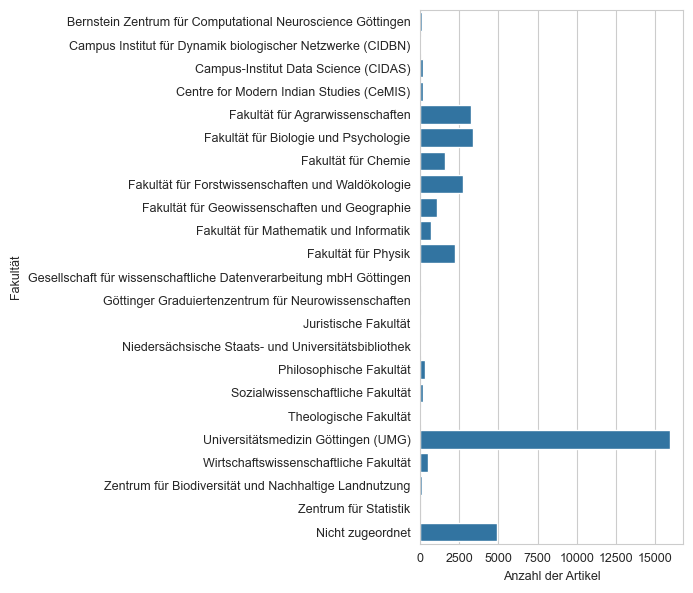

In [1028]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 6))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [1029]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8698846306855854